## 1 · Install dependencies

In [1]:

!pip install -q "deepgram-sdk==3.7.0" faster-whisper transformers torch torchaudio \
                librosa jiwer rapidfuzz pandas matplotlib soundfile "datasets==2.20.0" \
                indic-transliteration requests
print("Install complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.9/162.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

## 2 · Hugging Face login

In [2]:
from huggingface_hub import login
login('')

## 3 · API keys (Deepgram + Sarvam)

In [3]:
import os, torch
os.environ['DEEPGRAM_API_KEY'] = ''
os.environ['SARVAM_API_KEY']   = ''
print("Deepgram key set:", os.environ['DEEPGRAM_API_KEY'] != 'PASTE_YOUR_DEEPGRAM_KEY_HERE')
print("Sarvam key set:  ", os.environ['SARVAM_API_KEY'] != 'PASTE_YOUR_SARVAM_KEY_HERE')
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU - set Runtime to T4 GPU!")

Deepgram key set: True
Sarvam key set:   True
GPU: Tesla T4


## 4 · Shared helpers — metrics, transliteration, normalization

Defined once and reused everywhere (single source of truth for scoring).
Transliteration covers **both Hindi (Devanagari) and Kannada** scripts → Roman,
so a model that correctly transcribes Kannada in Kannada script is matched fairly
against the Roman-script locality names (not penalized for the script).

In [4]:
import re, time
import pandas as pd
from functools import lru_cache
import jiwer
from rapidfuzz import fuzz
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate

# Script ranges. We transliterate BOTH Hindi (Devanagari) and Kannada to Roman
# before matching, so a correct native-script transcription is not unfairly
# penalized against a Roman-script locality database.
DEV = re.compile(r'[\u0900-\u097F]')   # Devanagari (Hindi)
KAN = re.compile(r'[\u0C80-\u0CFF]')   # Kannada

def clean(t):
    """Strip wav2vec2 special tokens like <s>, </s>."""
    if not isinstance(t, str): return ""
    t = re.sub(r'</?s>', '', t)
    t = re.sub(r'<[^>]*>', '', t)
    return re.sub(r'\s+', ' ', t).strip()

def to_roman(t):
    """Transliterate Devanagari OR Kannada script to Roman (ITRANS) for fair matching."""
    if not isinstance(t, str) or not t.strip(): return ""
    try:
        if DEV.search(t):
            t = transliterate(t, sanscript.DEVANAGARI, sanscript.ITRANS)
        elif KAN.search(t):
            t = transliterate(t, sanscript.KANNADA, sanscript.ITRANS)
    except Exception:
        pass
    return t

def normalize(t):
    t = to_roman(clean(t)).lower()
    t = re.sub(r'[^a-z0-9 ]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

def compute_wer(ref, hyp):
    r, h = normalize(ref), normalize(hyp)
    if not r: return 1.0 if h else 0.0
    try: return jiwer.wer(r, h)
    except Exception: return 1.0

def compute_cer(ref, hyp):
    r, h = normalize(ref), normalize(hyp)
    if not r: return 1.0 if h else 0.0
    try: return jiwer.cer(r, h)
    except Exception: return 1.0

def entity_match(locality, hyp, thr=80):
    """Did the locality survive transcription? Fuzzy, cross-script aware (Hindi + Kannada)."""
    nl, nh = normalize(locality), normalize(hyp)
    if not nh: return False, 0
    s = fuzz.partial_ratio(nl, nh)
    return s >= thr, int(s)


import librosa as _lb
def audio_duration_seconds(path):
    """Duration of an audio file in seconds (for Real-Time Factor)."""
    try:
        return _lb.get_duration(path=path)
    except Exception:
        try:
            y, sr = _lb.load(path, sr=None, mono=True); return len(y)/sr
        except Exception:
            return None

def entity_char_distance(locality, hyp):
    """Near-miss quality: 0=perfect, 1=totally wrong. Low=recoverable by fuzzy lookup."""
    nl, nh = normalize(locality), normalize(hyp)
    if not nh: return 1.0
    score = fuzz.partial_ratio(nl, nh)
    return round(1.0 - score/100.0, 3)

print("Helpers ready: Kannada transliteration + RTF + entity-distance.")

Helpers ready: Kannada transliteration + RTF + entity-distance.


## 5 · The 4 transcribers

Each returns a dict: {transcript, latency_seconds}. Models are loaded once and cached.

In [5]:

WHISPER_LANG = {"hindi":"hi","hinglish":"hi","kannada":"kn","english":"en"}
INDIC_LANG   = {"hindi":"hi","hinglish":"hi","kannada":"kn","english":"hi"}
SARVAM_LANG  = {"hindi":"hi-IN","hinglish":"hi-IN","kannada":"kn-IN","english":"en-IN"}
DEEPGRAM_LANG= {"hindi":"multi","hinglish":"multi","kannada":"multi","english":"multi"}

def deepgram_transcribe(audio_path, language="multi", model="nova-3"):
    from deepgram import DeepgramClient
    client = DeepgramClient(os.environ["DEEPGRAM_API_KEY"])
    with open(audio_path, "rb") as f: buf = f.read()
    start = time.perf_counter(); resp = None
    try:
        resp = client.listen.v1.media.transcribe_file(
            request=buf, model=model, language=language, smart_format=True, punctuate=True)
    except (AttributeError, TypeError):
        resp = None
    if resp is None:
        from deepgram import PrerecordedOptions
        opts = PrerecordedOptions(model=model, language=language, smart_format=True, punctuate=True)
        resp = client.listen.rest.v("1").transcribe_file({"buffer": buf}, opts)
    lat = time.perf_counter() - start
    try: tx = resp.results.channels[0].alternatives[0].transcript
    except Exception:
        d = resp.to_dict() if hasattr(resp,"to_dict") else resp
        try: tx = d["results"]["channels"][0]["alternatives"][0]["transcript"]
        except Exception: tx = ""
    return {"transcript": tx, "latency_seconds": round(lat,3)}

# ---- Sarvam Saarika (API, India-specific, Deepgram competitor) ----
import requests
def sarvam_transcribe(audio_path, language_code="unknown", model="saarika:v2.5"):
    url = "https://api.sarvam.ai/speech-to-text"
    headers = {"api-subscription-key": os.environ["SARVAM_API_KEY"]}
    start = time.perf_counter()
    with open(audio_path, "rb") as f:
        files = {"file": (os.path.basename(audio_path), f, "audio/wav")}
        data = {"model": model, "language_code": language_code}
        r = requests.post(url, headers=headers, files=files, data=data, timeout=60)
    lat = time.perf_counter() - start
    try: tx = r.json().get("transcript", "")
    except Exception: tx = ""
    return {"transcript": tx, "latency_seconds": round(lat,3)}

# ---- Whisper large-v3 (faster-whisper, multilingual) ----
from faster_whisper import WhisperModel
@lru_cache(maxsize=2)
def _wh(size):
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    ct  = "int8_float16" if dev=="cuda" else "int8"
    try: return WhisperModel(size, device=dev, compute_type=ct)
    except Exception: return WhisperModel(size, device="cpu", compute_type="int8")

def whisper_transcribe(audio_path, size="large-v3", language="hi"):
    model = _wh(size)
    start = time.perf_counter()
    segs, _ = model.transcribe(audio_path, language=language, beam_size=5)
    tx = " ".join(s.text.strip() for s in segs)
    return {"transcript": tx.strip(), "latency_seconds": round(time.perf_counter()-start,3)}

# ---- IndicConformer-600M-Multi (open, all 22 Indian langs, per-language decoding) ----
import torchaudio
@lru_cache(maxsize=1)
def _conformer():
    from transformers import AutoModel
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    m = AutoModel.from_pretrained("ai4bharat/indic-conformer-600m-multilingual",
                                  trust_remote_code=True).to(dev).eval()
    return m, dev

def indicconformer_transcribe(audio_path, language="hi", decoding="ctc"):
    model, dev = _conformer()
    wav, sr = torchaudio.load(audio_path)
    wav = torch.mean(wav, dim=0, keepdim=True)
    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)
    start = time.perf_counter()
    with torch.no_grad():
        tx = model(wav.to(dev), language, decoding)
    if isinstance(tx, (list, tuple)): tx = tx[0] if tx else ""
    return {"transcript": str(tx).strip(), "latency_seconds": round(time.perf_counter()-start,3)}

# ---- IndicWav2Vec (Vakyansh Hindi, open, Hindi-only) ----
import librosa
@lru_cache(maxsize=1)
def _w2v():
    from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
    mid = "Harveenchadha/vakyansh-wav2vec2-hindi-him-4200"
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    proc = Wav2Vec2Processor.from_pretrained(mid)
    mdl  = Wav2Vec2ForCTC.from_pretrained(mid).to(dev).eval()
    return mdl, proc, dev

def indicwav2vec_transcribe(audio_path, language="hi"):
    mdl, proc, dev = _w2v()
    audio, _ = librosa.load(audio_path, sr=16000, mono=True)
    iv = proc(audio, sampling_rate=16000, return_tensors="pt").input_values.to(dev)
    start = time.perf_counter()
    with torch.no_grad(): logits = mdl(iv).logits
    ids = torch.argmax(logits, dim=-1)
    tx = proc.batch_decode(ids)[0]
    return {"transcript": clean(tx), "latency_seconds": round(time.perf_counter()-start,3)}

# MODELS take (audio_path, lang_label) so we can route the correct language per clip.
# lang_label is one of: hindi / hinglish / kannada / english
MODELS = {
    "deepgram_nova3":   lambda p, lang: deepgram_transcribe(p, language=DEEPGRAM_LANG.get(lang,"multi")),
    "sarvam_saarika":   lambda p, lang: sarvam_transcribe(p, language_code=SARVAM_LANG.get(lang,"unknown")),
    "whisper_large_v3": lambda p, lang: whisper_transcribe(p, size="large-v3", language=WHISPER_LANG.get(lang,"hi")),
    "indicconformer":   lambda p, lang: indicconformer_transcribe(p, language=INDIC_LANG.get(lang,"hi")),
    "indicwav2vec":     lambda p, lang: indicwav2vec_transcribe(p, language="hi"),  # Hindi-only by design
}
print("Transcribers ready:", list(MODELS.keys()))

Transcribers ready: ['deepgram_nova3', 'sarvam_saarika', 'whisper_large_v3', 'indicconformer', 'indicwav2vec']


## 6 · Your own recordings — upload + convert


In [6]:
from google.colab import files
import os, soundfile as sf

os.makedirs('recordings_raw', exist_ok=True)
os.makedirs('recordings', exist_ok=True)
up = files.upload()  # select all 20 audio files
for fn in list(up.keys()):
    os.rename(fn, os.path.join('recordings_raw', fn))

AUDIO_EXTS = {'.m4a','.mp3','.wav','.ogg','.flac','.aac','.opus','.mp4','.mov','.3gp','.amr','.webm'}
for f in sorted(os.listdir('recordings_raw')):
    ext = os.path.splitext(f)[1].lower()
    if ext not in AUDIO_EXTS: continue
    audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
    out = os.path.splitext(f)[0] + '.wav'
    sf.write(os.path.join('recordings', out), audio, 16000)
    print(f"converted {f} -> {out}")
print("\nDone. Files in recordings/:", len(os.listdir('recordings')))

Saving 01_koramangala_quiet_hinglish.mp4 to 01_koramangala_quiet_hinglish.mp4
Saving 04_electronic_city_quiet_hinglish.mp4 to 04_electronic_city_quiet_hinglish.mp4
Saving 09_yelahanka_quiet_english.mp4 to 09_yelahanka_quiet_english.mp4
Saving 06_jayanagar_quiet_kannada.mp4 to 06_jayanagar_quiet_kannada.mp4
Saving 03_whitefield_phone_english.mp4 to 03_whitefield_phone_english.mp4
Saving 08_hebbal_phone_hinglish.mp4 to 08_hebbal_phone_hinglish.mp4
Saving 13_majestic_phone_hindi.mp4 to 13_majestic_phone_hindi.mp4
Saving 18_kr_puram_phone_hinglish.mp4 to 18_kr_puram_phone_hinglish.mp4
Saving 12_btm_layout_rushed_hinglish.mp4 to 12_btm_layout_rushed_hinglish.mp4
Saving 05_marathahalli_rushed_hinglish.mp4 to 05_marathahalli_rushed_hinglish.mp4
Saving 20_rajarajeshwarinagar_rushed_kannada.mp4 to 20_rajarajeshwarinagar_rushed_kannada.mp4
Saving 11_hsr_layout_whispered_english.mp4 to 11_hsr_layout_whispered_english.mp4
Saving 16_sarjapur_whispered_hindi.mp4 to 16_sarjapur_whispered_hindi.mp4
Sa

/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


converted 01_koramangala_quiet_hinglish.mp4 -> 01_koramangala_quiet_hinglish.wav
converted 02_indiranagar_noisy_hinglish.mp4 -> 02_indiranagar_noisy_hinglish.wav


/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


converted 03_whitefield_phone_english.mp4 -> 03_whitefield_phone_english.wav
converted 04_electronic_city_quiet_hinglish.mp4 -> 04_electronic_city_quiet_hinglish.wav


...

/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


converted 17_kadugondanahalli_noisy_hindi.mp4 -> 17_kadugondanahalli_noisy_hindi.wav
converted 18_kr_puram_phone_hinglish.mp4 -> 18_kr_puram_phone_hinglish.wav


/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


converted 19_byatarayanapura_quiet_hindi.mp4 -> 19_byatarayanapura_quiet_hindi.wav
converted 20_rajarajeshwarinagar_rushed_kannada.mp4 -> 20_rajarajeshwarinagar_rushed_kannada.wav

Done. Files in recordings/: 20


/tmp/ipykernel_712/1013183138.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(os.path.join('recordings_raw', f), sr=16000, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## 7 · Ground truth for your recordings (Original Sentences)



In [7]:

import os
if not os.path.exists('ground_truth.csv') and not __import__('glob').glob('/content/**/ground_truth.csv', recursive=True):
    from google.colab import files
    up = files.upload()
    print("Uploaded:", list(up.keys()))
else:
    print("ground_truth.csv already present — skip this cell.")

Saving ground_truth.csv to ground_truth.csv
Uploaded: ['ground_truth.csv']


In [8]:

import os, glob, pandas as pd

gt_path = None
for cand in ['ground_truth.csv'] + glob.glob('/content/**/ground_truth.csv', recursive=True):
    if os.path.exists(cand):
        gt_path = cand
        break

assert gt_path is not None, "ground_truth.csv not found. Upload it or unzip your project first."
print("Loading ground truth from:", gt_path)

gt = pd.read_csv(gt_path)
present = set(os.listdir('recordings')) if os.path.exists('recordings') else set()
gt = gt[gt['filename'].isin(present)].reset_index(drop=True)
print(f"{len(gt)} of {sum(1 for _ in open(gt_path))-1} recordings present and matched.")
gt.head()

Loading ground truth from: ground_truth.csv
20 of 20 recordings present and matched.


,filename,locality,reference,condition,language
0,01_koramangala_quiet_hinglish.wav,Koramangala,Haan bhaiya main Koramangala mein rehta hoon,quiet,hinglish
1,02_indiranagar_noisy_hinglish.wav,Indiranagar,Indiranagar ke paas hi hai mera ghar,noisy,hinglish
2,03_whitefield_phone_english.wav,Whitefield,Yeah I stay in Whitefield near the metro,phone,english
3,04_electronic_city_quiet_hinglish.wav,Electronic City,Electronic City Phase 1 mein job karta hoon,quiet,hinglish
4,05_marathahalli_rushed_hinglish.wav,Marathahalli,Marathahalli bus stop ke paas,rushed,hinglish


## 8 · Run all models on YOUR recordings

In [9]:
import traceback
rows = []
for mname, fn in MODELS.items():
    print(f"\n=== {mname} ===")
    for _, r in gt.iterrows():
        path = os.path.join('recordings', r['filename'])
        dur = audio_duration_seconds(path)
        try:
            res = fn(path, r['language'])
            m, s = entity_match(r['locality'], res['transcript'])
            lat = res['latency_seconds']
            rtf = round(lat/dur, 3) if (dur and dur > 0) else None
            rows.append({"dataset":"own","model":mname,"item":r['locality'],
                         "condition":r['condition'],"language":r['language'],
                         "reference":r['reference'],"transcript":res['transcript'],
                         "audio_seconds":round(dur,3) if dur else None,
                         "latency_seconds":lat,"rtf":rtf,
                         "wer":round(compute_wer(r['reference'],res['transcript']),3),
                         "cer":round(compute_cer(r['reference'],res['transcript']),3),
                         "entity_matched":m,"entity_score":s,
                         "entity_distance":entity_char_distance(r['locality'],res['transcript'])})
            print(f"  {r['locality']:<20} ({r['language']:<8}) match={m} rtf={rtf}")
        except Exception as e:
            print(f"  ERROR {r['locality']}: {str(e)[:90]}")
own_df = pd.DataFrame(rows)
own_df.to_csv('results_own.csv', index=False)
print("\nSaved results_own.csv —", len(own_df), "rows")



=== deepgram_nova3 ===
  Koramangala          (hinglish) match=False rtf=0.323
  Indiranagar          (hinglish) match=True rtf=0.379
  Whitefield           (english ) match=True rtf=0.307
  Electronic City      (hinglish) match=True rtf=0.257
  Marathahalli         (hinglish) match=True rtf=0.333
  Jayanagar            (kannada ) match=True rtf=0.281
  Rajajinagar          (hindi   ) match=True rtf=0.292
  Hebbal               (hinglish) match=False rtf=0.295
  Yelahanka            (english ) match=True rtf=0.317
  Banashankari         (kannada ) match=True rtf=0.29
  HSR Layout           (english ) match=True rtf=0.31
  BTM Layout           (hinglish) match=True rtf=0.413
  Majestic             (hindi   ) match=True rtf=0.267
  Silk Board           (english ) match=True rtf=0.512
  Bellandur            (hinglish) match=True rtf=0.316
  Sarjapur             (hindi   ) match=True rtf=0.31
  Kadugondanahalli     (hindi   ) match=False rtf=0.449
  KR Puram             (hinglish) match=T

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  Koramangala          (hinglish) match=True rtf=0.474
  Indiranagar          (hinglish) match=True rtf=0.279
  Whitefield           (english ) match=True rtf=0.171
  Electronic City      (hinglish) match=False rtf=0.256
  Marathahalli         (hinglish) match=True rtf=1.153
  Jayanagar            (kannada ) match=True rtf=0.244
  Rajajinagar          (hindi   ) match=True rtf=0.277
  Hebbal               (hinglish) match=False rtf=0.226
  Yelahanka            (english ) match=True rtf=0.159
  Banashankari         (kannada ) match=True rtf=0.215
  HSR Layout           (english ) match=True rtf=0.136
  BTM Layout           (hinglish) match=False rtf=0.268
  Majestic             (hindi   ) match=True rtf=0.261
  Silk Board           (english ) match=True rtf=0.27
  Bellandur            (hinglish) match=True rtf=0.236
  Sarjapur             (hindi   ) match=True rtf=0.253
  Kadugondanahalli     (hindi   ) match=True rtf=0.358
  KR Puram             (hinglish) match=False rtf=0.223
  Byata

config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

model_onnx.py: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

  Koramangala          (hinglish) match=True rtf=0.256
  Indiranagar          (hinglish) match=False rtf=0.011
  Whitefield           (english ) match=False rtf=0.01
  Electronic City      (hinglish) match=False rtf=0.009
  Marathahalli         (hinglish) match=False rtf=0.009
  Jayanagar            (kannada ) match=True rtf=0.008
  Rajajinagar          (hindi   ) match=True rtf=0.006
  Hebbal               (hinglish) match=False rtf=0.005
  Yelahanka            (english ) match=False rtf=0.005
  Banashankari         (kannada ) match=True rtf=0.005
  HSR Layout           (english ) match=False rtf=0.005
  BTM Layout           (hinglish) match=False rtf=0.006
  Majestic             (hindi   ) match=False rtf=0.005
  Silk Board           (english ) match=True rtf=0.007
  Bellandur            (hinglish) match=False rtf=0.005
  Sarjapur             (hindi   ) match=False rtf=0.005
  Kadugondanahalli     (hindi   ) match=False rtf=0.007
  KR Puram             (hinglish) match=False rtf=0.00

## 9 · Load open-source datasets (Common Voice + Kathbath)


In [10]:
from datasets import load_dataset
N_SAMPLES = 20
open_clips = []
cv_loaded = 0
def _try_cv(repo, **kw):
    global cv_loaded
    try:
        ds = load_dataset(repo, "hi", split="test", streaming=True, **kw)
        cnt = 0
        for ex in ds:
            audio = ex.get("audio") or ex.get("path")
            arr = audio["array"] if isinstance(audio, dict) else None
            sr  = audio["sampling_rate"] if isinstance(audio, dict) else None
            sent = ex.get("sentence") or ex.get("text") or ""
            if arr is None: continue
            open_clips.append(("common_voice", arr, sr, sent))
            cnt += 1
            if cnt >= N_SAMPLES: break
        cv_loaded = cnt
        return cnt > 0
    except Exception as e:
        print(f"  CV via {repo}: {str(e)[:120]}")
        return False

if not _try_cv("mozilla-foundation/common_voice_17_0", trust_remote_code=True):
    if not _try_cv("mozilla-foundation/common_voice_13_0", trust_remote_code=True):
        _try_cv("fsicoli/common_voice_17_0", trust_remote_code=True)
print(f"Common Voice: loaded {cv_loaded} samples")

# ---------- Kathbath Hindi ----------

kb_loaded = 0
try:
    kb = load_dataset("ai4bharat/Kathbath", "hindi", split="valid", streaming=True)
    cnt = 0
    for ex in kb:
        audio = ex.get("audio_filepath") or ex.get("audio")
        text  = ex.get("text") or ex.get("transcript") or ""
        if audio is None or not text: continue

        if isinstance(audio, dict):
            arr, sr = audio["array"], audio["sampling_rate"]
        else:

            try:
                samples = audio.get_all_samples()
                arr = samples.data.squeeze().cpu().numpy()
                sr  = samples.sample_rate
            except Exception:
                continue
        open_clips.append(("kathbath", arr, sr, text))
        cnt += 1
        if cnt >= N_SAMPLES: break
    kb_loaded = cnt
except Exception as e:
    print("  Kathbath error:", str(e)[:160])
print(f"Kathbath: loaded {kb_loaded} samples")

print("\nTotal open-source clips:", len(open_clips))

  CV via mozilla-foundation/common_voice_17_0: The directory at hf://datasets/mozilla-foundation/common_voice_17_0@11dc88355e899d1bf2df74f01b904a8544a17b33 doesn't con


Repo card metadata block was not found. Setting CardData to empty.


  CV via mozilla-foundation/common_voice_13_0: The directory at hf://datasets/mozilla-foundation/common_voice_13_0@ff2bbb54dcdb597100fe534a1b911ff9103f9e22 doesn't con


Reading metadata...: 3154it [00:00, 10735.08it/s]


Common Voice: loaded 20 samples


Resolving data files:   0%|          | 0/22 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Kathbath: loaded 20 samples

Total open-source clips: 40


## 10 · Run models on open-source data → WER/CER



In [11]:
import soundfile as sf, tempfile, numpy as np, librosa as lb

OPEN_MODELS = dict(MODELS)   # all 5; comment out Deepgram/Sarvam here to save API credits

open_rows = []
for i, (dsname, arr, sr, ref) in enumerate(open_clips):
    tmp = tempfile.mktemp(suffix=".wav")
    a = np.asarray(arr, dtype="float32")
    if sr != 16000:
        a = lb.resample(a, orig_sr=sr, target_sr=16000)
    sf.write(tmp, a, 16000)
    for mname, fn in OPEN_MODELS.items():
        try:
            res = fn(tmp, "hindi")   # open datasets here are Hindi
            open_rows.append({"dataset":dsname,"model":mname,"item":f"{dsname}_{i}",
                              "reference":ref,"transcript":res["transcript"],
                              "latency_seconds":res["latency_seconds"],
                              "wer":round(compute_wer(ref,res["transcript"]),3),
                              "cer":round(compute_cer(ref,res["transcript"]),3)})
        except Exception as e:
            print(f"  ERROR {dsname}#{i} {mname}: {str(e)[:80]}")
    if (i+1) % 10 == 0: print(f"  processed {i+1}/{len(open_clips)} clips")
    os.remove(tmp)

open_df = pd.DataFrame(open_rows)
open_df.to_csv('results_open.csv', index=False)
print("\nSaved results_open.csv —", len(open_df), "rows")

  processed 10/40 clips
  processed 20/40 clips
  processed 30/40 clips
  processed 40/40 clips

Saved results_open.csv — 200 rows


## 11 · Results

Two tables:
- **Own recordings:** entity accuracy + WER/CER + latency, sliced by condition and language
- **Open data:** WER/CER per model per dataset

In [12]:
print("="*60)
print("A) YOUR RECORDINGS — primary metric: entity accuracy")
print("="*60)
agg_own = own_df.groupby("model").agg(
    entity_accuracy=("entity_matched","mean"),
    wer_mean=("wer","mean"), cer_mean=("cer","mean"),
    latency_p50=("latency_seconds","median"),
    n=("item","count")).round(3).sort_values("entity_accuracy", ascending=False)
display(agg_own)
agg_own.to_csv("agg_own.csv")

print("\nEntity accuracy by CONDITION:")
display(own_df.pivot_table(index="model", columns="condition", values="entity_matched", aggfunc="mean").round(2))
print("\nEntity accuracy by LANGUAGE:")
display(own_df.pivot_table(index="model", columns="language", values="entity_matched", aggfunc="mean").round(2))

if len(open_df):
    print("\n" + "="*60)
    print("B) OPEN-SOURCE DATA — metric: WER / CER (lower = better)")
    print("="*60)
    agg_open = open_df.groupby(["dataset","model"]).agg(
        wer_mean=("wer","mean"), cer_mean=("cer","mean"),
        latency_p50=("latency_seconds","median"), n=("item","count")).round(3)
    display(agg_open)
    agg_open.to_csv("agg_open.csv")
else:
    print("\n(No open-source data loaded — skipping section B)")

A) YOUR RECORDINGS — primary metric: entity accuracy


,entity_accuracy,wer_mean,cer_mean,latency_p50,n
model,,,,,
deepgram_nova3,0.85,0.742,0.210,1.488,20
whisper_large_v3,0.80,0.873,0.295,1.163,20
sarvam_saarika,0.75,0.826,0.291,0.632,20
indicconformer,0.70,0.992,0.386,1.270,20
indicwav2vec,0.35,1.099,0.459,0.027,20



Entity accuracy by CONDITION:


condition,noisy,phone,quiet,rushed,whispered
model,,,,,
deepgram_nova3,0.8,0.75,0.83,1.00,1.0
indicconformer,1.0,0.50,0.67,0.67,0.5
indicwav2vec,0.6,0.00,0.50,0.33,0.0
sarvam_saarika,0.8,0.50,0.83,0.67,1.0
whisper_large_v3,1.0,0.50,0.83,0.67,1.0



Entity accuracy by LANGUAGE:


language,english,hindi,hinglish,kannada
model,,,,
deepgram_nova3,1.00,0.8,0.75,1.0
indicconformer,0.25,1.0,0.62,1.0
indicwav2vec,0.25,0.4,0.12,1.0
sarvam_saarika,1.00,0.8,0.50,1.0
whisper_large_v3,1.00,1.0,0.50,1.0



B) OPEN-SOURCE DATA — metric: WER / CER (lower = better)


wer_mean  cer_mean  latency_p50   n
dataset      model                                                
common_voice deepgram_nova3       0.192     0.083        1.484  20
             indicconformer       0.197     0.052        1.007  20
             indicwav2vec         0.211     0.065        0.021  20
             sarvam_saarika       0.140     0.050        0.660  20
             whisper_large_v3     0.260     0.098        1.355  20
kathbath     deepgram_nova3       0.210     0.072        1.288  20
             indicconformer       0.055     0.010        1.055  20
             indicwav2vec         0.120     0.023        0.021  20
             sarvam_saarika       0.089     0.021        0.723  20
             whisper_large_v3     0.169     0.049        1.863  20

## 11b · Some more decision metrics (RTF · near-miss quality)

- **Real-Time Factor (RTF)** = processing time / audio length. <1 = faster than real-time (can keep up with live calls); lower scales cheaper.
- **Mean entity distance on misses** = when the locality is missed, how close was it? 0 = perfect, 1 = totally wrong. Low values mean graceful failures recoverable by fuzzy-matching against the known-localities list; high values mean confidently-wrong outputs.


In [13]:
import numpy as np

prod = own_df.groupby("model").agg(
    rtf_p50=("rtf","median"),
    rtf_p95=("rtf", lambda s: s.quantile(0.95)),
).round(3)


miss = own_df[~own_df["entity_matched"]]
prod["miss_entity_distance"] = miss.groupby("model")["entity_distance"].mean().round(3)
prod["n_misses"] = miss.groupby("model")["item"].count()

prod = prod.sort_values("rtf_p50")
print("=== Production decision metrics (RTF + near-miss quality) ===")
display(prod)
prod.to_csv("prod_metrics.csv")


=== Production decision metrics (RTF + near-miss quality) ===


,rtf_p50,rtf_p95,miss_entity_distance,n_misses
model,,,,
indicwav2vec,0.006,0.023,0.345,13
sarvam_saarika,0.138,0.186,0.372,5
whisper_large_v3,0.254,0.508,0.314,4
indicconformer,0.256,0.375,0.357,6
deepgram_nova3,0.313,0.512,0.307,3


## 12 · Charts

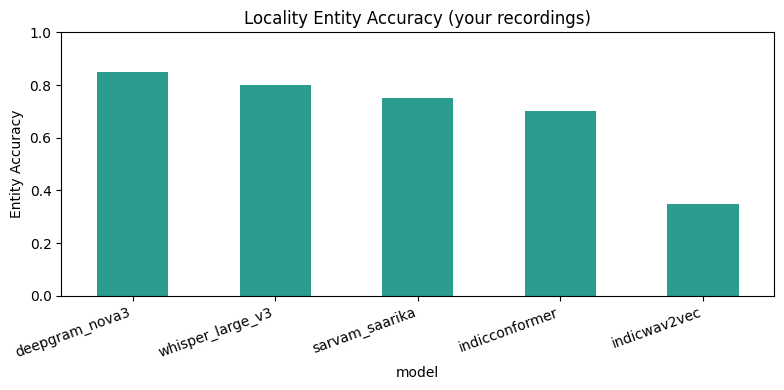

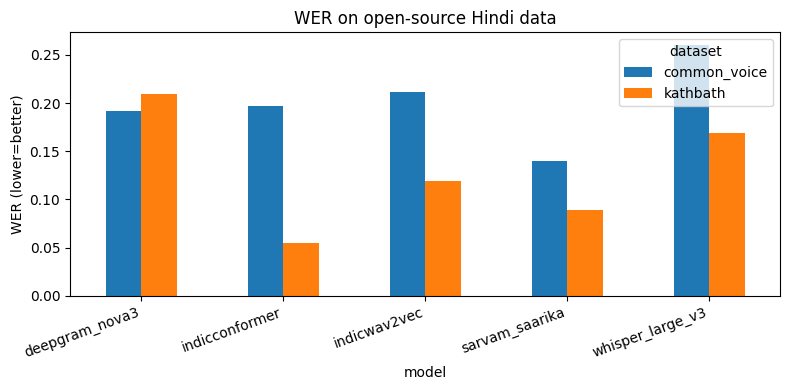

In [14]:
import matplotlib.pyplot as plt

# Entity accuracy bar (own recordings)
fig, ax = plt.subplots(figsize=(8,4))
agg_own["entity_accuracy"].plot(kind="bar", ax=ax, color="#2a9d8f")
ax.set_ylabel("Entity Accuracy"); ax.set_ylim(0,1); ax.set_title("Locality Entity Accuracy (your recordings)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.savefig("chart_entity.png", dpi=150); plt.show()

# WER on open data
if len(open_df):
    piv = open_df.pivot_table(index="model", columns="dataset", values="wer", aggfunc="mean")
    piv.plot(kind="bar", figsize=(8,4)); plt.ylabel("WER (lower=better)")
    plt.title("WER on open-source Hindi data"); plt.xticks(rotation=20, ha="right")
    plt.tight_layout(); plt.savefig("chart_wer_open.png", dpi=150); plt.show()

## 13 · Failure cases on your recordings (for the report)

In [15]:
fails = own_df[~own_df["entity_matched"]][["model","item","condition","language","transcript","entity_score"]]
fails = fails.sort_values("entity_score")
fails.to_csv("failures.csv", index=False)
print(f"{len(fails)} failure rows. Worst 15:")
import pandas as pd
pd.set_option("display.max_colwidth", 60)
display(fails.head(15))

31 failure rows. Worst 15:


,model,item,condition,language,transcript,entity_score
90,indicwav2vec,HSR Layout,whispered,english,ेसाले र सटरटो,44
27,sarvam_saarika,Hebbal,phone,hinglish,हिप्पल फ्लाईओवर के पास ड्रॉप कर देना।,50
82,indicwav2vec,Whitefield,phone,english,यह आसटे इन वाइट फील्ड नियर दमेटो,50
62,indicconformer,Whitefield,phone,english,या आई स्टे इन व्हाइट फील्ड नियर द मेट्रो,50
63,indicconformer,Electronic City,quiet,hinglish,इलेक्ट्रॉानिक सिटी फेज़ वन में जॉब करता हूं,53
51,whisper_large_v3,BTM Layout,rushed,hinglish,बीटीएम लेयाउट में ही घर है मेरा,60
31,sarvam_saarika,BTM Layout,rushed,hinglish,अरे बेटी एम लेआउट में ही घर है मेरा।,60
23,sarvam_saarika,Electronic City,quiet,hinglish,इलेक्ट्रॉनिक सिटी फ़ेज़ वन में जॉब करता हूँ,60
71,indicconformer,BTM Layout,rushed,hinglish,बीटीएम लेआउट में ही घर है मेरा,60
83,indicwav2vec,Electronic City,quiet,hinglish,इलेक्ट्रॉनिक सिटी फेस वन में जॉब करता हूं,60


## 14 · Download everything

In [17]:
from google.colab import files
import shutil, os
os.makedirs("bundle", exist_ok=True)
for f in ["results_own.csv","results_open.csv","agg_own.csv","agg_open.csv","failures.csv",
          "chart_entity.png","chart_wer_open.png"]:
    if os.path.exists(f): shutil.copy(f, "bundle/")
shutil.make_archive("asr_results", "zip", "bundle")
files.download("asr_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>